In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
import pandas as pd
df = pd.read_csv('/netflix_titles (1).csv')

In [28]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [29]:
df.shape

(8807, 12)

In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [31]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [32]:
df.duplicated().sum()

np.int64(0)

As Checked This dataset contains information about Netflix movies and TV shows available on the platform.
It includes details such as title, director, cast, country, release year, rating, and duration.
The dataset has multiple rows and columns representing different entertainment content.
Some columns contain missing values, which may require data cleaning before analysis.
This dataset can be used to analyze Netflix content trends, genres, and distribution patterns.


In [33]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [34]:
df = df.drop_duplicates()

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.isnull().sum().sort_values(ascending=False)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [37]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')

In [38]:
df = df.dropna(subset=['date_added'])

In [39]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,4
duration,3


In [40]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [41]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

In [42]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,4
duration,3


In [43]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


In [44]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [45]:
df = df.drop(columns=['show_id'])

In [46]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          8797 non-null   object        
 1   title         8797 non-null   object        
 2   director      8797 non-null   object        
 3   cast          8797 non-null   object        
 4   country       8797 non-null   object        
 5   date_added    8797 non-null   datetime64[ns]
 6   release_year  8797 non-null   int64         
 7   rating        8793 non-null   object        
 8   duration      8794 non-null   object        
 9   listed_in     8797 non-null   object        
 10  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 824.7+ KB


In [48]:
df.to_csv("cleaned_netflix_data.csv", index=False)

Data Cleaning :
In this step, the dataset was cleaned to improve data quality and make it suitable for analysis. Duplicate records were removed to avoid repeated information in the dataset. Missing values in columns like director, cast, and country were handled using appropriate placeholder values. Rows with missing date information were removed because date analysis is important in this project. The date_added column was converted into datetime format, and the show_id column was removed since it is only an identifier and not useful for analysis.

Step 2 : Summary

Today I cleaned the Netflix dataset by handling missing values, removing duplicate records, fixing data types, and removing irrelevant columns.
The cleaned dataset was saved for future exploratory data analysis and visualization tasks, these preprocessing steps improved the overall quality and consistency of the dataset.

In [49]:
df.shape


(8797, 11)

In [50]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          8797 non-null   object        
 1   title         8797 non-null   object        
 2   director      8797 non-null   object        
 3   cast          8797 non-null   object        
 4   country       8797 non-null   object        
 5   date_added    8797 non-null   datetime64[ns]
 6   release_year  8797 non-null   int64         
 7   rating        8793 non-null   object        
 8   duration      8794 non-null   object        
 9   listed_in     8797 non-null   object        
 10  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 824.7+ KB


#EDA  Questions

In [52]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2666


Movies are more than TV Shows in Netflix dataset

In [53]:
df['country'].value_counts().head(10)

,count
country,
United States,2812
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


United States has the highest number of titles

In [54]:
df['rating'].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


TV-MA is the most common rating category

In [55]:
df['release_year'].max()

2021

In [57]:
df['director'].value_counts().head(10)

,count
director,
Unknown,2624
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


# Visualizations

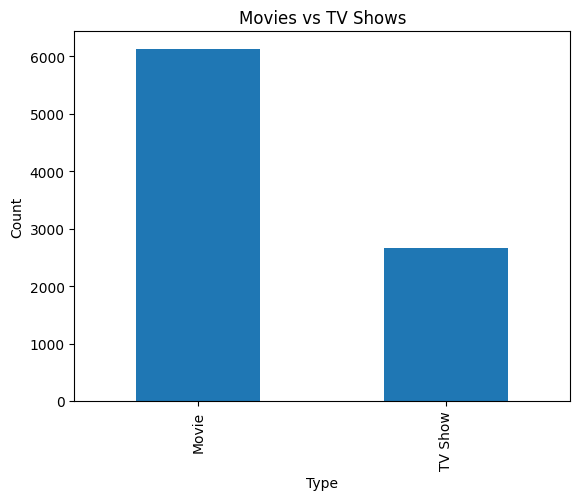

In [58]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

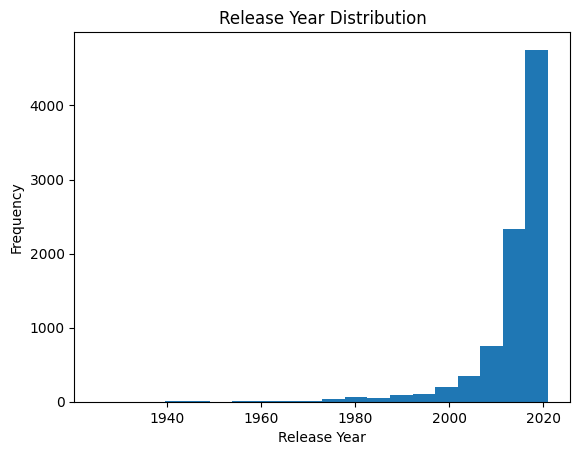

In [59]:
df['release_year'].plot(kind='hist', bins=20)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.show()

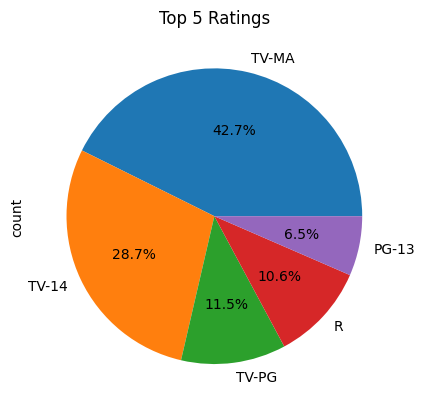

In [60]:
df['rating'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Top 5 Ratings")
plt.show()

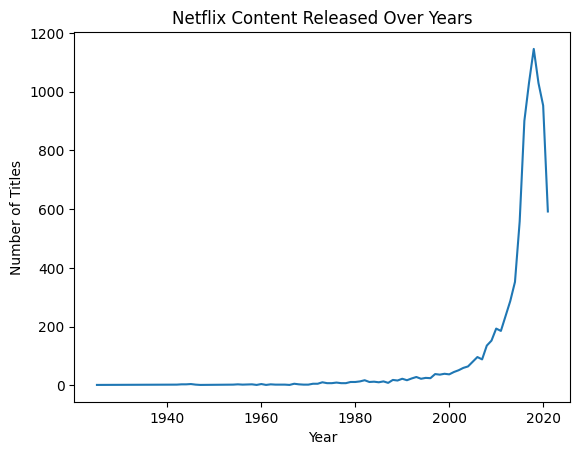

In [61]:
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title("Netflix Content Released Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()